In [4]:
import pandas as pd
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
conn = sqlite3.connect("/home/jayant/Music/Machine Learning Project/Invoice-Intelligence-ML-Project/data/inventory.db")
tables = pd.read_sql_query("Select name from sqlite_master  where type = 'table'",conn)

In [6]:
tables

,name
0,Purchases
1,Vendor_Invoice
2,Begin_Inventory
3,End_Inventory
4,Purchase_Prices


In [7]:
for table in tables ['name']:
    print('table name', table)
    df = pd.read_sql_query(f"select * from {table} limit 5", conn)
    display(df)

table name Purchases


,PO_Number,Brand,Item_Quantity,Dollars,PO_Date,Receiving_Date,Vendor_Number
0,PO102852,B0211,31,1339.51,2024-03-24,2024-04-06,V0087
1,PO102170,B0314,168,3491.04,2024-01-16,2024-01-25,V0020
2,PO100713,B0086,243,26001.00,2025-07-11,2025-07-12,V0083
3,PO100761,B0272,217,1373.61,2025-02-07,2025-02-18,V0107
4,PO104426,B0144,150,1306.50,2024-07-06,2024-07-08,V0143


table name Vendor_Invoice


,PO_Number,Quantity,Dollars,Freight_Cost,Invoice_Date,PO_Date,Pay_Date,Approval
0,PO100000,339,3975.77,70.02,2024-03-10,2024-03-06,2024-03-17,0
1,PO100001,499,5732.60,91.74,2025-07-27,2025-07-18,2025-08-21,0
2,PO100002,514,3863.89,79.63,2025-04-28,2025-04-22,2025-06-11,0
3,PO100003,355,4588.99,73.28,2024-11-22,2024-11-16,2025-01-06,0
4,PO100005,448,7645.91,103.23,2025-09-30,2025-09-18,2025-10-26,0


table name Begin_Inventory


,Brand,Description,Quantity,Inventory_Value,Inventory_Date
0,B0001,Product 0001,4165,73131.61,2024-01-01
1,B0002,Product 0002,1008,16887.28,2024-01-01
2,B0003,Product 0003,1910,17475.46,2024-01-01
3,B0004,Product 0004,2798,58519.06,2024-01-01
4,B0005,Product 0005,1479,4593.05,2024-01-01


table name End_Inventory


,Brand,Description,Quantity,Inventory_Value,Inventory_Date
0,B0001,Product 0001,5203,46785.66,2025-12-31
1,B0002,Product 0002,739,6290.19,2025-12-31
2,B0003,Product 0003,1363,15856.01,2025-12-31
3,B0004,Product 0004,2961,88994.35,2025-12-31
4,B0005,Product 0005,2162,14760.51,2025-12-31


table name Purchase_Prices


,Brand,Vendor_Number,Purchase_Price,Description
0,B0211,V0087,14.29,Product 0211
1,B0314,V0020,46.03,Product 0314
2,B0086,V0083,8.45,Product 0086
3,B0272,V0107,8.82,Product 0272
4,B0144,V0143,50.73,Product 0144


In [8]:
vendor_df = pd.read_sql_query("select * from Vendor_Invoice", conn)
vendor_df.head()

,PO_Number,Quantity,Dollars,Freight_Cost,Invoice_Date,PO_Date,Pay_Date,Approval
0,PO100000,339,3975.77,70.02,2024-03-10,2024-03-06,2024-03-17,0
1,PO100001,499,5732.60,91.74,2025-07-27,2025-07-18,2025-08-21,0
2,PO100002,514,3863.89,79.63,2025-04-28,2025-04-22,2025-06-11,0
3,PO100003,355,4588.99,73.28,2024-11-22,2024-11-16,2025-01-06,0
4,PO100005,448,7645.91,103.23,2025-09-30,2025-09-18,2025-10-26,0


In [9]:
vendor_df[['Quantity', 'Freight_Cost', 'Dollars']].corr()

,Quantity,Freight_Cost,Dollars
Quantity,1.000000,0.782887,0.674371
Freight_Cost,0.782887,1.000000,0.986377
Dollars,0.674371,0.986377,1.000000


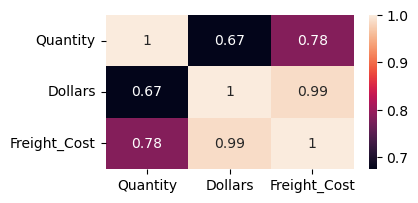

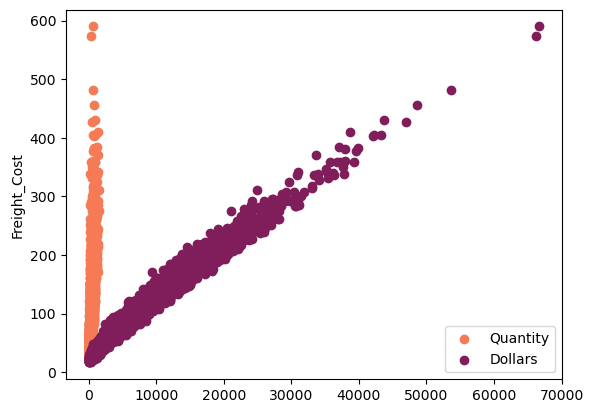

In [10]:
plt.figure(figsize = (4,2))
sns.heatmap(vendor_df[['Quantity', 'Dollars' , 'Freight_Cost']].corr(), annot = True)
plt.show()
plt.scatter(vendor_df['Quantity'],  vendor_df['Freight_Cost'], color = '#f57a55')
plt.scatter(vendor_df['Dollars'],  vendor_df['Freight_Cost'], color = '#7f1e5a')
plt.legend(['Quantity', 'Dollars'])
plt.ylabel('Freight_Cost')
plt.show()



In [11]:
vendor_df ['frieght_per_unit'] = vendor_df['Freight_Cost']/vendor_df['Quantity']

In [12]:
low_quantity = vendor_df['Quantity'].quantile(0.25)
high_quantity = vendor_df['Quantity'].quantile(0.75)

In [13]:
low_quantity

191.0

In [14]:
high_quantity

508.75

In [15]:
vendor_df.loc[vendor_df['Quantity'] < low_quantity,'frieght_per_unit'].mean()

0.6120246174734225

In [16]:
vendor_df.loc[vendor_df['Quantity'] > high_quantity,'frieght_per_unit'].mean()

0.23240469976587547

In [17]:
X = vendor_df[[ 'Dollars']]
y= vendor_df['Freight_Cost']

In [18]:
vendor_df.describe().round()

,Quantity,Dollars,Freight_Cost,Approval,frieght_per_unit
count,4878.0,4878.0,4878.0,4878.0,4878.0
mean,371.0,6885.0,95.0,0.0,0.0
std,244.0,6511.0,62.0,0.0,1.0
min,1.0,5.0,17.0,0.0,0.0
25%,191.0,2252.0,50.0,0.0,0.0
50%,318.0,4937.0,80.0,0.0,0.0
75%,509.0,9490.0,124.0,0.0,0.0
max,1575.0,66720.0,590.0,0.0,22.0


In [19]:
from sklearn.model_selection import train_test_split

In [20]:
X_train , X_test, y_train , y_test = train_test_split(X,y, test_size = 0.2, random_state = 42) 

In [21]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score 

In [22]:
model1 = LinearRegression()
model1.fit(X_train,y_train)

model2 = DecisionTreeRegressor(max_depth =6,random_state =42)
model2.fit(X_train,y_train)

model3 = RandomForestRegressor(max_depth =2,random_state =42)
model3.fit(X_train,y_train)

RandomForestRegressor(max_depth=2, random_state=42)

In [23]:
def evaluate_model(model, X_test, y_test, model_name):
    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = mean_squared_error(y_test, preds) ** 0.5
    r2 = r2_score(y_test, preds) * 100

    print(f"\n{model_name} Performance:")
    print(f"MAE : {mae:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"R2 : {r2:.2f}%")

In [24]:
evaluate_model(model1, X_test, y_test, 'LinearRegression')
evaluate_model(model2, X_test, y_test, 'DecisionTreeRegressor')
evaluate_model(model3, X_test, y_test, 'RandomForestRegressor')


LinearRegression Performance:
MAE : 7.81
RMSE : 10.53
R2 : 96.86%

DecisionTreeRegressor Performance:
MAE : 7.29
RMSE : 10.00
R2 : 97.18%

RandomForestRegressor Performance:
MAE : 14.80
RMSE : 19.29
R2 : 89.49%


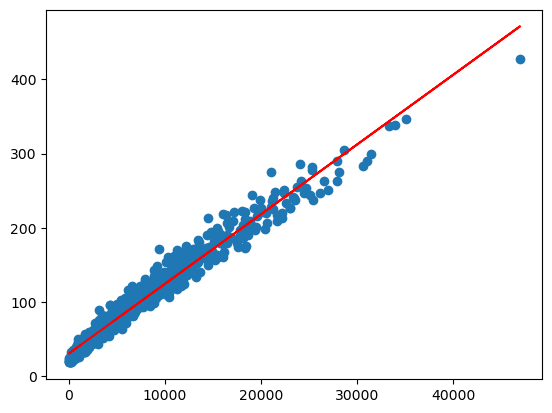

In [25]:
plt.scatter(X_test, y_test)
plt.plot(X_test, model1.predict(X_test),color = 'red')

In [27]:
input_data = {
    "Dollars" : [18500,9500],
}
df = pd.DataFrame(input_data)

In [29]:
model1.predict(df)

array([204.41428117, 119.94114395])